In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import json
import ast
from scipy.signal import savgol_filter
mpl.rcParams.update({
    "text.usetex": True,              # Enable LaTeX
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"], # Use Times New Roman
    "text.latex.preamble": r"\usepackage{amsmath}"
})

In [2]:
def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [3]:
def feet_world_to_base(feet_pos_w, base_pos_w, base_rpy):
    """
    feet_pos_w: (N, n_feet, 3) or (n_feet, 3)
    base_pos_w: (N, 3) or (3,)
    base_rpy:   (N, 3) or (3,)
    returns:    feet_pos_b with same leading shape as feet_pos_w
    """
    feet_pos_w = np.asarray(feet_pos_w)
    base_pos_w = np.asarray(base_pos_w)
    base_rpy   = np.asarray(base_rpy)

    # Ensure batch dimension
    if feet_pos_w.ndim == 2:
        feet_pos_w = feet_pos_w[None, ...]
        base_pos_w = base_pos_w[None, ...]
        base_rpy   = base_rpy[None, ...]

    # Base rotation (base -> world)
    R_w_b = rpy_to_rotmat(base_rpy)

    # Relative foot position in world frame
    p_rel_w = feet_pos_w - base_pos_w[:, None, :]

    # Rotate into base frame: R^T (p_w - p_b)
    feet_pos_b = np.einsum('nij,nfj->nfi', R_w_b.transpose(0, 2, 1), p_rel_w)

    return feet_pos_b


In [4]:
def single_foot_world_to_base(foot_pos_w, base_pos_w, base_rpy):
    """
    foot_pos_w: (N, 3) or (3,)
    base_pos_w: (N, 3) or (3,)
    base_rpy:   (N, 3) or (3,)
    returns:    foot_pos_b with shape (N, 3) or (3,)
    """
    foot_pos_w = np.asarray(foot_pos_w)
    base_pos_w = np.asarray(base_pos_w)
    base_rpy   = np.asarray(base_rpy)

    single = False
    if foot_pos_w.ndim == 1:
        single = True
        foot_pos_w = foot_pos_w[None, :]
        base_pos_w = base_pos_w[None, :]
        base_rpy   = base_rpy[None, :]

    # Base rotation (base → world)
    R_w_b = rpy_to_rotmat(base_rpy)   # (N, 3, 3)

    # Relative foot position in world frame
    p_rel_w = foot_pos_w - base_pos_w  # (N, 3)

    # Rotate into base frame: p_b = R^T (p_w − p_b)
    foot_pos_b = np.einsum('nij,nj->ni', R_w_b.transpose(0, 2, 1), p_rel_w)
    # foot_pos_b = R_w_b.transpose(0, 2, 1) @ p_rel_w

    return foot_pos_b[0] if single else foot_pos_b

In [5]:
side_signs = np.array([-1,1,-1,1])

l1 = 0.08
l2 = 0.213
l3 = 0.216
l4 = 0.0

def calculated_desired_foot_pose(leg_idx, acts):
    side_sign = side_signs[leg_idx]
    
    act_foot_poses = []

    for act in acts:
        q_0 = act[0]
        q_1 = -act[1]
        q_2 = -act[2]

        s1 = np.sin(q_0)
        s2 = np.sin(q_1)
        s3 = np.sin(q_2)

        c1 = np.cos(q_0)
        c2 = np.cos(q_1)
        c3 = np.cos(q_2)

        c23 = c2*c3 - s2*s3
        s23 = s2*c3 + c2*s3

        pos = []

        pos.append(l3*s23 - l2*s2)
        pos.append((l1+l4) * side_sign * c1 + l3*(s1*c23) + l2*c2*s1)
        pos.append((l1+l4) * side_sign * s1 - l3*(c1*c23) - l2*c1 *c2)

        act_foot_poses.append(pos)
    
    return np.array(act_foot_poses)

In [6]:
# Define a function to convert the string representation of an array/list
def string_to_array(array_string):
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        return ast.literal_eval(array_string)
    except (ValueError, SyntaxError):
        # Handle cases where the string might not be a valid list/array string
        return array_string # Or some default/error value

In [7]:
exp_filepath = "exp_data/full_trained_model_forward_turn/full_12Lwater_push.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_12Lwater_push.csv"


payload_df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(payload_df))

800


In [8]:
exp_filepath = "exp_data/full_trained_model_forward_turn/full_0Lnone_push.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_0Lnone_push.csv"


noload_df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(noload_df))

800


In [9]:
# Joint tracking / violation metrics
q_actions      = np.array(payload_df["q_des"].to_list())
q_observations = np.array(payload_df["dof_pose"].to_list())

# cmd tracking metrics
vel_cmds = np.array(payload_df["base_cmd"].to_list())  # v_x, v_y, w_yaw
lin_vel  = np.array(payload_df["base_lin_vel"].to_list())
ang_vel  = np.array(payload_df["base_ang_vel"].to_list())   # stability via roll/pitch angular velo.

# Height tracking metric
base_pose = np.array(payload_df["base_pose"].to_list())
base_rpy = np.array(payload_df["base_rpy"].to_list())

# Oreintation
proj_grav = np.array(payload_df["proj_grav"].to_list())

foot_pose = np.array(payload_df["feet_pos"].to_list())

# joint power metric
q_vel = np.array(payload_df["dof_vel"].to_list())
q_tau = np.array(payload_df["tau_act"].to_list())
# alignment metric, ratio metric
ff_tau = np.array(payload_df["tau_ff"].to_list())
pd_tau = np.array(payload_df["tau_pd"].to_list())

grfs = np.array(payload_df["grf"].to_list())
grf_pred = np.array(payload_df["pred_grf"].to_list())

joint_limits = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])

joint_torque_limits = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

In [10]:
front_both_contact = payload_df[(np.array(payload_df["grf"].to_list())[:,2] > 10.0) & (np.array(payload_df["grf"].to_list())[:,5] > 10.0)]
rear_both_contact =  payload_df[(np.array(payload_df["grf"].to_list())[:,8] > 10.0) & (np.array(payload_df["grf"].to_list())[:,11] > 10.0)]

nl_front_both_contact = noload_df[(np.array(noload_df["grf"].to_list())[:,2] > 10.0) & (np.array(noload_df["grf"].to_list())[:,5] > 10.0)]
nl_rear_both_contact =  noload_df[(np.array(noload_df["grf"].to_list())[:,8] > 10.0) & (np.array(noload_df["grf"].to_list())[:,11] > 10.0)]

In [11]:
len(nl_front_both_contact)

9

In [12]:
fr_act_poses_both_contact = calculated_desired_foot_pose(0,np.array(front_both_contact["q_des"].to_list())[:,[0,1,2]])
nl_fr_act_poses_both_contact = calculated_desired_foot_pose(0,np.array(nl_front_both_contact["q_des"].to_list())[:,[0,1,2]])

fl_act_poses_both_contact = calculated_desired_foot_pose(1,np.array(front_both_contact["q_des"].to_list())[:,[3,4,5]])
nl_fl_act_poses_both_contact = calculated_desired_foot_pose(1,np.array(nl_front_both_contact["q_des"].to_list())[:,[3,4,5]])

# rr_act_poses_both_contact = calculated_desired_foot_pose(2,np.array(rear_both_contact["q_des"].to_list())[:,[6,7,8]])
# nl_rr_act_poses_both_contact = calculated_desired_foot_pose(2,np.array(nl_rear_both_contact["q_des"].to_list())[:,[6,7,8]])

# rl_act_poses_both_contact = calculated_desired_foot_pose(3,np.array(rear_both_contact["q_des"].to_list())[:,[9,10,11]])
# nl_rl_act_poses_both_contact = calculated_desired_foot_pose(3,np.array(nl_rear_both_contact["q_des"].to_list())[:,[9,10,11]])


In [13]:
contact_width = np.abs(fr_act_poses_both_contact[:,1] - fl_act_poses_both_contact[:,1])
nl_contact_width = np.abs(nl_fr_act_poses_both_contact[:,1] - nl_fl_act_poses_both_contact[:,1])

In [14]:
print(np.mean(contact_width))
print(np.mean(nl_contact_width))

0.15172553112047404
0.16253724449873017


In [15]:
fr_act_poses = calculated_desired_foot_pose(0,np.array(payload_df["q_des"].to_list())[:,[0,1,2]])
nl_fr_act_poses = calculated_desired_foot_pose(0,np.array(noload_df["q_des"].to_list())[:,[0,1,2]])

fl_act_poses = calculated_desired_foot_pose(1,np.array(payload_df["q_des"].to_list())[:,[3,4,5]])
nl_fl_act_poses = calculated_desired_foot_pose(1,np.array(noload_df["q_des"].to_list())[:,[3,4,5]])

In [16]:
contact_width = np.abs(fr_act_poses[:,1] - fl_act_poses[:,1])
nl_contact_width = np.abs(nl_fr_act_poses[:,1] - nl_fl_act_poses[:,1])

In [17]:
print(np.mean(contact_width))
print(np.mean(nl_contact_width))

0.08868661239300117
0.13519398209425149


In [18]:
front_right_contact = payload_df[(np.array(payload_df["grf"].to_list())[:,2] > 1.0)]
front_left_contact = payload_df[(np.array(payload_df["grf"].to_list())[:,5] > 1.0)]
rear_right_contact = payload_df[(np.array(payload_df["grf"].to_list())[:,8] > 1.0)]
rear_left_contact = payload_df[(np.array(payload_df["grf"].to_list())[:,11] > 1.0)]

In [19]:
fr_foot_pose_base = single_foot_world_to_base(np.array(front_right_contact["feet_pos"].to_list())[:,0,:], 
                                              np.array(front_right_contact["base_pose"].to_list()), 
                                              np.array(front_right_contact["base_rpy"].to_list()))

fl_foot_pose_base = single_foot_world_to_base(np.array(front_left_contact["feet_pos"].to_list())[:,0,:], 
                                              np.array(front_left_contact["base_pose"].to_list()), 
                                              np.array(front_left_contact["base_rpy"].to_list()))

rr_foot_pose_base = single_foot_world_to_base(np.array(rear_right_contact["feet_pos"].to_list())[:,0,:], 
                                              np.array(rear_right_contact["base_pose"].to_list()), 
                                              np.array(rear_right_contact["base_rpy"].to_list()))

rl_foot_pose_base = single_foot_world_to_base(np.array(rear_left_contact["feet_pos"].to_list())[:,0,:], 
                                              np.array(rear_left_contact["base_pose"].to_list()), 
                                              np.array(rear_left_contact["base_rpy"].to_list()))

In [20]:
nl_front_right_contact = noload_df[(np.array(noload_df["grf"].to_list())[:,2] > 1.0)]
nl_front_left_contact  = noload_df[(np.array(noload_df["grf"].to_list())[:,5] > 1.0)]
nl_rear_right_contact  = noload_df[(np.array(noload_df["grf"].to_list())[:,8] > 1.0)]
nl_rear_left_contact   = noload_df[(np.array(noload_df["grf"].to_list())[:,11] > 1.0)]

In [21]:
nl_fr_foot_pose_base = single_foot_world_to_base(np.array(nl_front_right_contact["feet_pos"].to_list())[:,0,:], 
                                                 np.array(nl_front_right_contact["base_pose"].to_list()), 
                                                 np.array(nl_front_right_contact["base_rpy"].to_list()))

nl_fl_foot_pose_base = single_foot_world_to_base(np.array(nl_front_left_contact["feet_pos"].to_list())[:,0,:], 
                                                 np.array(nl_front_left_contact["base_pose"].to_list()), 
                                                 np.array(nl_front_left_contact["base_rpy"].to_list()))

nl_rr_foot_pose_base = single_foot_world_to_base(np.array(nl_rear_right_contact["feet_pos"].to_list())[:,0,:], 
                                                 np.array(nl_rear_right_contact["base_pose"].to_list()), 
                                                 np.array(nl_rear_right_contact["base_rpy"].to_list()))

nl_rl_foot_pose_base = single_foot_world_to_base(np.array(nl_rear_left_contact["feet_pos"].to_list())[:,0,:], 
                                                 np.array(nl_rear_left_contact["base_pose"].to_list()), 
                                                 np.array(nl_rear_left_contact["base_rpy"].to_list()))

In [22]:
fr_gootpos_norm = np.linalg.norm(fr_foot_pose_base[:,:2], axis=1)
print("Front-Right Contact - ", np.round(np.mean(fr_gootpos_norm), 4))

fl_gootpos_norm = np.linalg.norm(fl_foot_pose_base[:,:2], axis=1)
print("Front-Left Contact - ", np.round(np.mean(fl_gootpos_norm), 4))

rr_gootpos_norm = np.linalg.norm(rr_foot_pose_base[:,:2], axis=1)
print("Rear-Right Contact - ", np.round(np.mean(rr_gootpos_norm), 4))

rl_gootpos_norm = np.linalg.norm(rl_foot_pose_base[:,:2], axis=1)
print("Rear-Left Contact - ", np.round(np.mean(rl_gootpos_norm), 4))


total_norms = np.concatenate([fr_gootpos_norm, fl_gootpos_norm, rr_gootpos_norm, rl_gootpos_norm], axis=0)
print("Total Contact - ", np.round(np.mean(total_norms), 4))

# Front-Right Contact -  0.2029
# Front-Left Contact -  0.2458
# Rear-Right Contact -  0.2421
# Rear-Left Contact -  0.2143

Front-Right Contact -  0.1875
Front-Left Contact -  0.2306
Rear-Right Contact -  0.2096
Rear-Left Contact -  0.2262
Total Contact -  0.2145


In [23]:
nl_fr_gootpos_norm = np.linalg.norm(nl_fr_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_fr_gootpos_norm), 4))

nl_fl_gootpos_norm = np.linalg.norm(nl_fl_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_fl_gootpos_norm), 4))

nl_rr_gootpos_norm = np.linalg.norm(nl_rr_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_rr_gootpos_norm), 4))

nl_rl_gootpos_norm = np.linalg.norm(nl_rl_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_rl_gootpos_norm), 4))

nl_total_norms = np.concatenate([nl_fr_gootpos_norm, nl_fl_gootpos_norm, nl_rr_gootpos_norm, nl_rl_gootpos_norm], axis=0)
print("NL Total Contact - ", np.round(np.mean(nl_total_norms), 4))

# NL Front-Right Contact -  0.1927b
# NL Front-Right Contact -  0.2369
# NL Front-Right Contact -  0.2411
# NL Front-Right Contact -  0.2015

NL Front-Right Contact -  0.2029
NL Front-Right Contact -  0.2427
NL Front-Right Contact -  0.2495
NL Front-Right Contact -  0.2185
NL Total Contact -  0.2282


In [24]:
from scipy import stats
t_ind, p_ind = stats.ttest_ind(nl_total_norms, total_norms, equal_var=False)
print(t_ind)
print(p_ind)

6.2149599467358465
5.805090531812715e-10


In [25]:
all_foot_poses = np.concatenate([fr_foot_pose_base[:,:2], fl_foot_pose_base[:,:2], rr_foot_pose_base[:,:2], rl_foot_pose_base[:,:2]], axis=0)

angles = np.arctan(np.abs(all_foot_poses[:,0]) / np.abs(all_foot_poses[:,1]))

np.mean(angles * (180.0/np.pi))

np.float64(65.12105904523602)

In [26]:
nl_all_foot_poses = np.concatenate([nl_fr_foot_pose_base[:,:2], nl_fl_foot_pose_base[:,:2], nl_rr_foot_pose_base[:,:2], nl_rl_foot_pose_base[:,:2]], axis=0)

nl_angles = np.arctan(np.abs(nl_all_foot_poses[:,0]) / np.abs(nl_all_foot_poses[:,1]))

np.mean(nl_angles * (180.0/np.pi))

np.float64(60.61320319122151)

In [27]:
np.array(payload_df["q_des"].to_list())
fr_foot_pose_base = single_foot_world_to_base(np.array(front_right_contact["feet_pos"].to_list())[:,0,:], 
                                              np.array(front_right_contact["base_pose"].to_list()), 
                                              np.array(front_right_contact["base_rpy"].to_list()))

In [28]:
fr_act_poses = calculated_desired_foot_pose(0,np.array(front_right_contact["q_des"].to_list())[:,[0,1,2]])
nl_fr_act_poses = calculated_desired_foot_pose(0,np.array(nl_front_right_contact["q_des"].to_list())[:,[0,1,2]])

fl_act_poses = calculated_desired_foot_pose(1,np.array(front_left_contact["q_des"].to_list())[:,[3,4,5]])
nl_fl_act_poses = calculated_desired_foot_pose(1,np.array(nl_front_left_contact["q_des"].to_list())[:,[3,4,5]])

rr_act_poses = calculated_desired_foot_pose(2,np.array(rear_right_contact["q_des"].to_list())[:,[6,7,8]])
nl_rr_act_poses = calculated_desired_foot_pose(2,np.array(nl_rear_right_contact["q_des"].to_list())[:,[6,7,8]])

rl_act_poses = calculated_desired_foot_pose(3,np.array(rear_left_contact["q_des"].to_list())[:,[9,10,11]])
nl_rl_act_poses = calculated_desired_foot_pose(3,np.array(nl_rear_left_contact["q_des"].to_list())[:,[9,10,11]])

fr_act_pose_norm = np.linalg.norm(fr_act_poses[:,:2], axis=1)
nl_fr_act_pose_norm = np.linalg.norm(nl_fr_act_poses[:,:2], axis=1)

fl_act_pose_norm = np.linalg.norm(fl_act_poses[:,:2], axis=1)
nl_fl_act_pose_norm = np.linalg.norm(nl_fl_act_poses[:,:2], axis=1)

rr_act_pose_norm = np.linalg.norm(rr_act_poses[:,:2], axis=1)
nl_rr_act_pose_norm = np.linalg.norm(nl_rr_act_poses[:,:2], axis=1)

rl_act_pose_norm = np.linalg.norm(rl_act_poses[:,:2], axis=1)
nl_rl_act_pose_norm = np.linalg.norm(nl_rl_act_poses[:,:2], axis=1)

total_act_norms = np.concatenate([fr_act_pose_norm, fl_act_pose_norm, rr_act_pose_norm, rl_act_pose_norm], axis=0)
print("Total Contact - ", np.round(np.mean(total_act_norms), 4))

nl_total_act_norms = np.concatenate([nl_fr_act_pose_norm, nl_fl_act_pose_norm, nl_rr_act_pose_norm, nl_rl_act_pose_norm], axis=0)
print("NL Total Contact - ", np.round(np.mean(nl_total_act_norms), 4))


Total Contact -  0.2255
NL Total Contact -  0.2788


In [29]:
all_foot_poses = np.concatenate([fr_act_poses[:,:2], fl_act_poses[:,:2], rr_act_poses[:,:2], rl_act_poses[:,:2]], axis=0)

angles = np.arctan(np.abs(all_foot_poses[:,0]) / np.abs(all_foot_poses[:,1]))

np.mean(angles * (180.0/np.pi))

np.float64(76.38355748802636)

In [30]:
all_foot_poses = np.concatenate([nl_fr_act_poses[:,:2], nl_fl_act_poses[:,:2], nl_rr_act_poses[:,:2], nl_rl_act_poses[:,:2]], axis=0)

angles = np.arctan(np.abs(all_foot_poses[:,0]) / np.abs(all_foot_poses[:,1]))

np.mean(angles * (180.0/np.pi))

np.float64(78.25311534576257)

In [31]:
print(np.mean(fr_act_pose_norm))
print(np.mean(nl_fr_act_pose_norm))
print()
print(np.mean(fl_act_pose_norm))
print(np.mean(nl_fl_act_pose_norm))
print()
print(np.mean(rr_act_pose_norm))
print(np.mean(nl_rr_act_pose_norm))
print()
print(np.mean(rl_act_pose_norm))
print(np.mean(nl_rl_act_pose_norm))

0.2182467311617223
0.2888452907210887

0.2231275437935528
0.2721232575430668

0.2293888722366085
0.27423667368827376

0.22988632990368268
0.2802981184726151


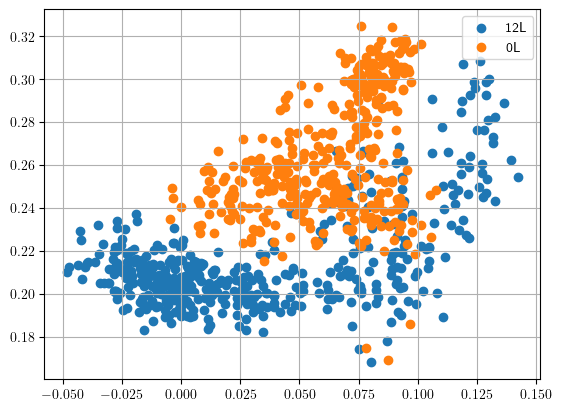

In [32]:
plt.scatter(fl_act_poses[:,1], fl_act_poses[:,0], label="12L")
plt.scatter(nl_fl_act_poses[:,1], nl_fl_act_poses[:,0], label="0L")
plt.grid()
plt.legend()

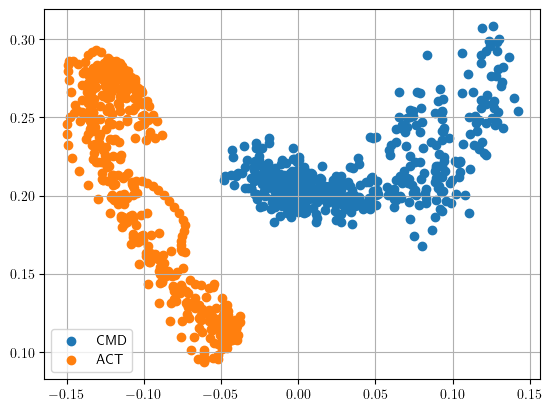

In [33]:
plt.scatter(fl_act_poses[:,1], fl_act_poses[:,0], label="CMD")
plt.scatter(fl_foot_pose_base[:,1], fl_foot_pose_base[:,0], label="ACT")
plt.grid()
plt.legend()

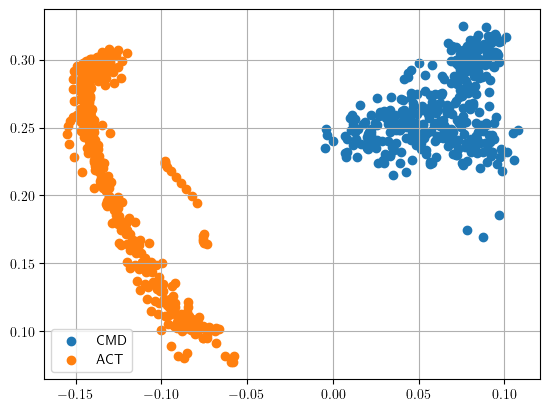

In [34]:
plt.scatter(nl_fl_act_poses[:,1], nl_fl_act_poses[:,0], label="CMD")
plt.scatter(nl_fl_foot_pose_base[:,1], nl_fl_foot_pose_base[:,0], label="ACT")
plt.grid()
plt.legend()

In [35]:
# DF row - Type [Obs., CMD.], Payload [12L, 0L], Value [Front-left footstep location]

type_labels = ["Obs." for _ in range(len(fl_foot_pose_base))]
type_labels.extend(["CMD" for _ in range(len(fl_act_poses))])
type_labels.extend(["Obs." for _ in range(len(nl_fl_foot_pose_base))])
type_labels.extend(["CMD" for _ in range(len(nl_fl_act_poses))])

payload_labels = ["12L" for _ in range(len(fl_foot_pose_base))]
payload_labels.extend(["12L" for _ in range(len(fl_act_poses))])
payload_labels.extend(["0L" for _ in range(len(nl_fl_foot_pose_base))])
payload_labels.extend(["0L" for _ in range(len(nl_fl_act_poses))])


value = []
value.extend(fl_foot_pose_base[:,1].tolist())
value.extend(fl_act_poses[:,1].tolist())
value.extend(nl_fl_foot_pose_base[:,1].tolist())
value.extend(nl_fl_act_poses[:,1].tolist())


temp_df = pd.DataFrame()

temp_df["Type"] = type_labels
temp_df["Payload"] = payload_labels
temp_df["Y-Step"] = value

Text(0, 0.5, 'Feedforward Torque Norm (Nm)')

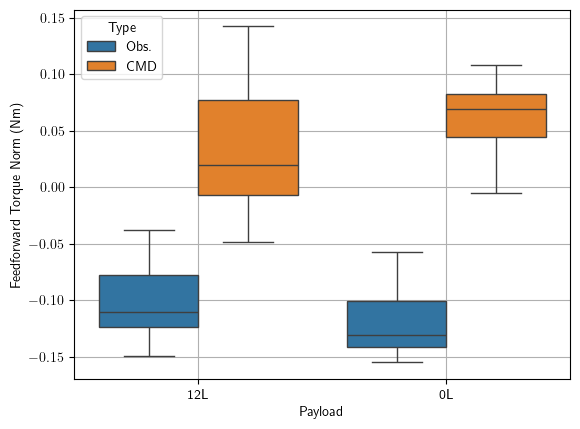

In [36]:
ax = sns.boxplot(data=temp_df, x="Payload", y="Y-Step", hue="Type", showfliers=False)
ax.grid()
ax.set_ylabel("Feedforward Torque Norm (Nm)")

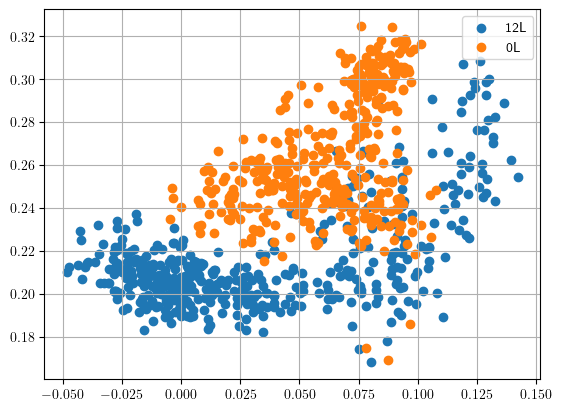

In [37]:
plt.scatter(fl_act_poses[:,1], fl_act_poses[:,0], label="12L")
plt.scatter(nl_fl_act_poses[:,1], nl_fl_act_poses[:,0], label="0L")
plt.grid()
plt.legend()

In [38]:
print("Front-Right")
print(np.mean(np.abs(fr_act_poses[:,1])))
print(np.mean(np.abs(nl_fr_act_poses[:,1])))
print()
print("Front-Left")
print(np.mean(np.abs(fl_act_poses[:,1])))
print(np.mean(np.abs(nl_fl_act_poses[:,1])))
print()
print("Rear-Right")
print(np.mean(np.abs(rr_act_poses[:,1])))
print(np.mean(np.abs(nl_rr_act_poses[:,1])))
print()
print("Rear-Left")
print(np.mean(np.abs(rl_act_poses[:,1])))
print(np.mean(np.abs(nl_rl_act_poses[:,1])))
print()

Front-Right
0.04083889562429616
0.03860316924884318

Front-Left
0.04528066283566873
0.06268035313462046

Rear-Right
0.08289891124607462
0.066639013874128

Rear-Left
0.040695975476101015
0.058322244854515023



In [39]:
print("Front-Right")
print(np.mean(np.abs(fr_act_poses[:,0])))
print(np.mean(np.abs(nl_fr_act_poses[:,0])))
print()
print("Front-Left")
print(np.mean(np.abs(fl_act_poses[:,0])))
print(np.mean(np.abs(nl_fl_act_poses[:,0])))
print()
print("Rear-Right")
print(np.mean(np.abs(rr_act_poses[:,0])))
print(np.mean(np.abs(nl_rr_act_poses[:,0])))
print()
print("Rear-Left")
print(np.mean(np.abs(rl_act_poses[:,0])))
print(np.mean(np.abs(nl_rl_act_poses[:,0])))
print()

Front-Right
0.21301241663796075
0.28467338999124087

Front-Left
0.2156648685571222
0.2638067003380005

Rear-Right
0.21258784139310974
0.2644489632775347

Rear-Left
0.225208661300239
0.2729977002416321



In [40]:
feet_pos_b = feet_world_to_base(foot_pose, base_pose, base_rpy)

In [41]:
left_feet_xy = feet_pos_b[:, [1,3], :2]
right_feet_xy = feet_pos_b[:, [0,2], :2]

print(left_feet_xy.shape)

(800, 2, 2)


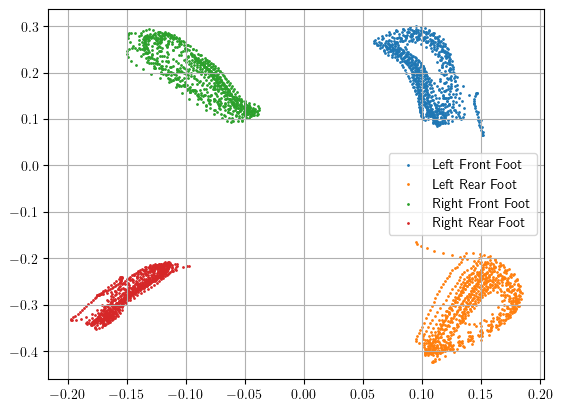

In [42]:
plt.scatter(left_feet_xy[:,0,1], left_feet_xy[:,0,0], label='Left Front Foot', s=1)
plt.scatter(left_feet_xy[:,1,1], left_feet_xy[:,1,0], label='Left Rear Foot', s=1)
plt.scatter(right_feet_xy[:,0,1], right_feet_xy[:,0,0], label='Right Front Foot', s=1)
plt.scatter(right_feet_xy[:,1,1], right_feet_xy[:,1,0], label='Right Rear Foot', s=1)

plt.grid()
plt.legend()

In [43]:
# ff_tau = np.array(payload_df["tau_ff"].to_list())
# pd_tau = np.array(payload_df["tau_pd"].to_list())

In [44]:
# Height tracking metric
nl_base_pose = np.array(noload_df["base_pose"].to_list())
nl_base_rpy = np.array(noload_df["base_rpy"].to_list())

nl_foot_pose = np.array(noload_df["feet_pos"].to_list())

nl_ff_tau = np.array(noload_df["tau_ff"].to_list())
nl_pd_tau = np.array(noload_df["tau_pd"].to_list())

# Joint tracking / violation metrics
nl_q_actions      = np.array(noload_df["q_des"].to_list())
nl_q_observations = np.array(noload_df["dof_pose"].to_list())

In [45]:
nl_feet_pos_b = feet_world_to_base(nl_foot_pose, nl_base_pose, nl_base_rpy)

In [46]:
nl_left_feet_xy = nl_feet_pos_b[:, [1,3], :2]
nl_right_feet_xy = nl_feet_pos_b[:, [0,2], :2]

print(nl_left_feet_xy.shape)

(800, 2, 2)


<Axes: >

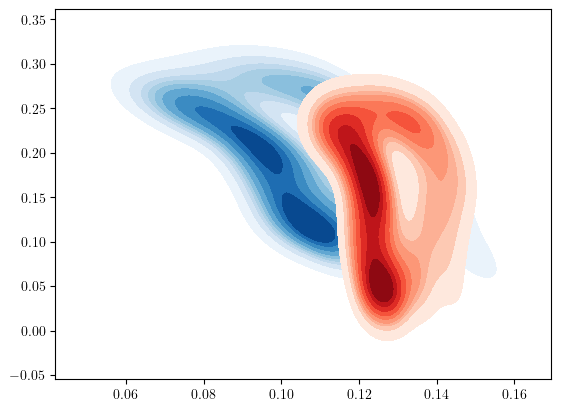

In [47]:
sns.kdeplot(x=left_feet_xy[:,0,1], y=left_feet_xy[:,0,0], cmap="Blues", fill=True)
sns.kdeplot(x=nl_left_feet_xy[:,0,1], y=nl_left_feet_xy[:,0,0], cmap="Reds", fill=True)

In [48]:
stance_width = np.abs(left_feet_xy[:,:,1] - right_feet_xy[:,:,1])  # shape: [timesteps, 2 front/rear]
front_width = stance_width[:,0]
rear_width = stance_width[:,1]

nl_stance_width = np.abs(nl_left_feet_xy[:,:,1] - nl_right_feet_xy[:,:,1])  # shape: [timesteps, 2 front/rear]
nl_front_width = nl_stance_width[:,0]
nl_rear_width = nl_stance_width[:,1]

In [49]:
print(np.mean(front_width))
print(np.mean(nl_front_width))

print(np.mean(rear_width))
print(np.mean(nl_rear_width))

0.19330045029171272
0.2349698853480065
0.2878409978322634
0.22717410109526712


In [50]:
# row - load, Feet Pair, then value

load_labels = ["10L" for _ in range(len(front_width))]
load_labels.extend(["0L" for _ in range(len(nl_front_width))])
load_labels.extend(["10L" for _ in range(len(rear_width))])
load_labels.extend(["0L" for _ in range(len(nl_rear_width))])

pair_labels = ["Front" for _ in range(len(front_width))]
pair_labels.extend(["Front" for _ in range(len(nl_front_width))])
pair_labels.extend(["Rear" for _ in range(len(rear_width))])
pair_labels.extend(["Rear" for _ in range(len(nl_rear_width))])


widths = []
widths.extend(front_width.tolist())
widths.extend(nl_front_width.tolist())
widths.extend(rear_width.tolist())
widths.extend(nl_rear_width.tolist())

temp_stance_df = pd.DataFrame()

temp_stance_df["Load"] = load_labels
temp_stance_df["Feet_Pair"] = pair_labels
temp_stance_df["Stance_Width"] = widths

Text(0, 0.5, 'Stance Width (m)')

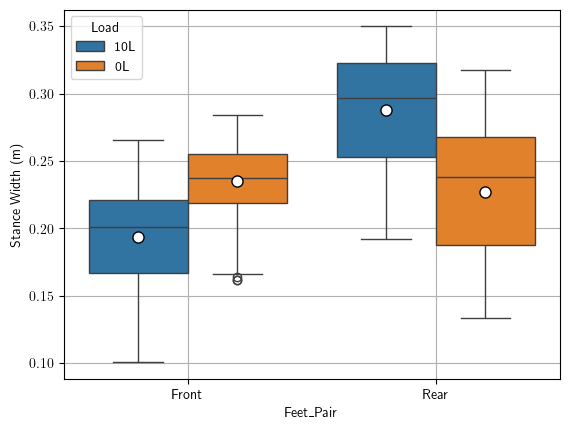

In [51]:
ax = sns.boxplot(data=temp_stance_df,
                 x="Feet_Pair",
                 y="Stance_Width",
                 hue="Load",
                 showmeans=True,
                     meanprops={
                         "marker": "o",   # Use a circle marker for the mean
                         "markerfacecolor": "white",
                         "markeredgecolor": "black",
                         "markersize": "8"
                         })
ax.grid()
ax.set_ylabel("Stance Width (m)")

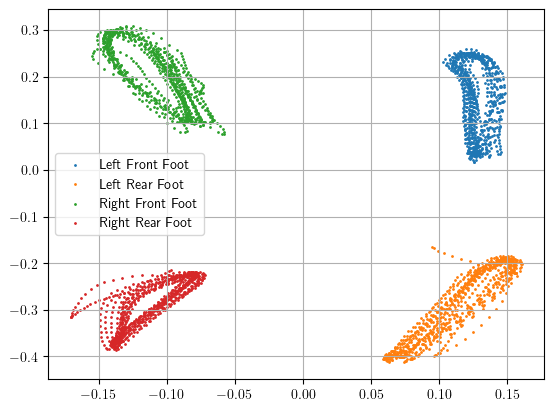

In [52]:
plt.scatter(nl_left_feet_xy[:,0,1], nl_left_feet_xy[:,0,0], label='Left Front Foot', s=1)
plt.scatter(nl_left_feet_xy[:,1,1], nl_left_feet_xy[:,1,0], label='Left Rear Foot', s=1)
plt.scatter(nl_right_feet_xy[:,0,1], nl_right_feet_xy[:,0,0], label='Right Front Foot', s=1)
plt.scatter(nl_right_feet_xy[:,1,1], nl_right_feet_xy[:,1,0], label='Right Rear Foot', s=1)

plt.grid()
plt.legend()

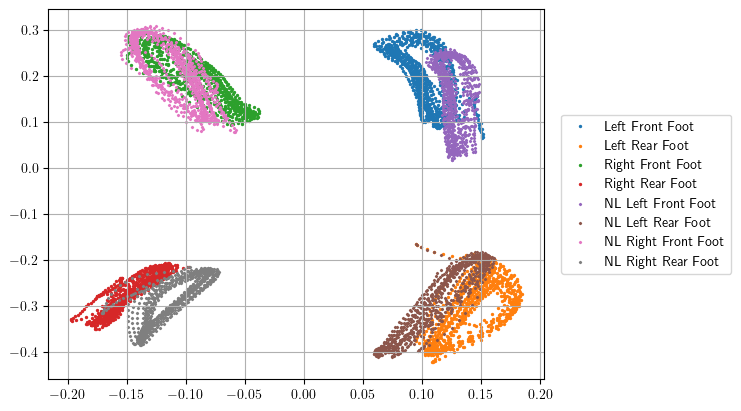

In [53]:
plt.scatter(left_feet_xy[:,0,1], left_feet_xy[:,0,0], label='Left Front Foot', s=2)
plt.scatter(left_feet_xy[:,1,1], left_feet_xy[:,1,0], label='Left Rear Foot', s=2)
plt.scatter(right_feet_xy[:,0,1], right_feet_xy[:,0,0], label='Right Front Foot', s=2)
plt.scatter(right_feet_xy[:,1,1], right_feet_xy[:,1,0], label='Right Rear Foot', s=2)
plt.scatter(nl_left_feet_xy[:,0,1], nl_left_feet_xy[:,0,0], label='NL Left Front Foot', s=2, marker="x")
plt.scatter(nl_left_feet_xy[:,1,1], nl_left_feet_xy[:,1,0], label='NL Left Rear Foot', s=2, marker="x")
plt.scatter(nl_right_feet_xy[:,0,1], nl_right_feet_xy[:,0,0], label='NL Right Front Foot', s=2, marker="x")
plt.scatter(nl_right_feet_xy[:,1,1], nl_right_feet_xy[:,1,0], label='NL Right Rear Foot', s=2, marker="x")
plt.grid()
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

<BarContainer object of 4 artists>

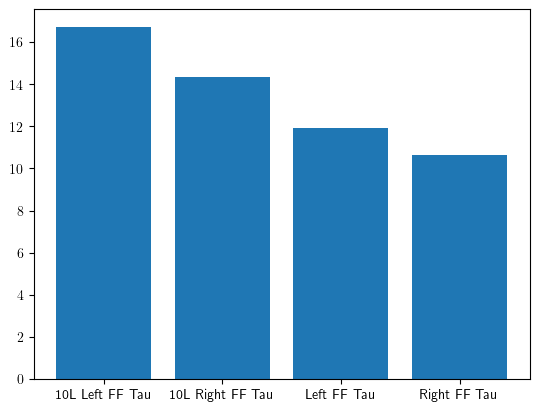

In [54]:
left_ff_tau = np.linalg.norm(ff_tau[:, [3,4,5,9,10,11]], axis=1)
right_ff_tau = np.linalg.norm(ff_tau[:, [0,1,2,6,7,8]], axis=1)

nl_left_ff_tau = np.linalg.norm(nl_ff_tau[:, [3,4,5,9,10,11]], axis=1)
nl_right_ff_tau = np.linalg.norm(nl_ff_tau[:, [0,1,2,6,7,8]], axis=1)

cat = ["10L Left FF Tau", "10L Right FF Tau", "Left FF Tau", "Right FF Tau"]
plt.bar(cat, [np.mean(left_ff_tau), np.mean(right_ff_tau), np.mean(nl_left_ff_tau), np.mean(nl_right_ff_tau)])

In [55]:
# DEF row - load, side, then value
# load as 10L Left, 0L left, 10L right, 0L right


load_labels = ["12L" for _ in range(len(left_ff_tau))]
load_labels.extend(["0L" for _ in range(len(nl_left_ff_tau))])
load_labels.extend(["12L" for _ in range(len(right_ff_tau))])
load_labels.extend(["0L" for _ in range(len(nl_right_ff_tau))])

side_labels = ["Left" for _ in range(len(left_ff_tau))]
side_labels.extend(["Left" for _ in range(len(nl_left_ff_tau))])
side_labels.extend(["Right" for _ in range(len(right_ff_tau))])
side_labels.extend(["Right" for _ in range(len(nl_right_ff_tau))])


value = []
value.extend(left_ff_tau.tolist())
value.extend(nl_left_ff_tau.tolist())
value.extend(right_ff_tau.tolist())
value.extend(nl_right_ff_tau.tolist())


temp_df = pd.DataFrame()

temp_df["Load"] = load_labels
temp_df["Side"] = side_labels
temp_df["FF_Tau_Norm"] = value

In [56]:
print(np.mean(left_ff_tau))
print(np.mean(right_ff_tau))

16.715323640208513
14.353367990116066


Text(0, 0.5, 'Feedforward Torque Norm (Nm)')

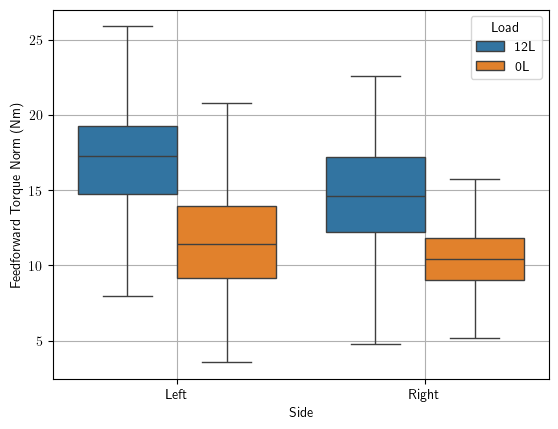

In [57]:
ax = sns.boxplot(data=temp_df, x="Side", y="FF_Tau_Norm", hue="Load", showfliers=False)
ax.grid()
ax.set_ylabel("Feedforward Torque Norm (Nm)")

/tmp/ipykernel_1439797/2208808853.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Left", "Right"], fontsize=16)
/tmp/ipykernel_1439797/2208808853.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)


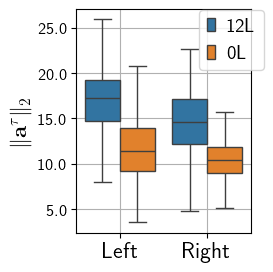

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(2.25, 2.9))

# ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$ and $\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$", fontsize=16)


sns.boxplot(data=temp_df, x="Side", y="FF_Tau_Norm", hue="Load", showfliers=False, ax=ax)
ax.grid()
ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$", fontsize=16)
ax.set_xlabel("", fontsize=1)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.65, 1.04),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=14,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
ax.set_xticklabels(["Left", "Right"], fontsize=16)
ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)

# ax.set_ylabel("PD Torque Norm (Nm)")
# fig.tight_layout()

fig.savefig(
    "ff_tau_side_vs_payload.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)

In [ ]:
left_pd_tau = np.sqrt(np.mean(np.square(q_actions[:, [3,4,5,9,10,11]] - q_observations[:, [3,4,5,9,10,11]]), axis=1))
right_pd_tau = np.sqrt(np.mean(np.square(q_actions[:, [0,1,2,6,7,8]] - q_observations[:, [0,1,2,6,7,8]]), axis=1))

nl_left_pd_tau = np.sqrt(np.mean(np.square(nl_q_actions[:, [3,4,5,9,10,11]] - nl_q_observations[:, [3,4,5,9,10,11]]), axis=1))
nl_right_pd_tau = np.sqrt(np.mean(np.square(nl_q_actions[:, [0,1,2,6,7,8]] - nl_q_observations[:, [0,1,2,6,7,8]]), axis=1))
# DEF row - load, side, then value
# load as 10L Left, 0L left, 10L right, 0L right


load_labels = ["10L" for _ in range(len(left_pd_tau))]
load_labels.extend(["0L" for _ in range(len(nl_left_pd_tau))])
load_labels.extend(["10L" for _ in range(len(right_pd_tau))])
load_labels.extend(["0L" for _ in range(len(nl_right_pd_tau))])

side_labels = ["Left" for _ in range(len(left_pd_tau))]
side_labels.extend(["Left" for _ in range(len(nl_left_pd_tau))])
side_labels.extend(["Right" for _ in range(len(right_pd_tau))])
side_labels.extend(["Right" for _ in range(len(nl_right_pd_tau))])


value = []
value.extend(left_pd_tau.tolist())
value.extend(nl_left_pd_tau.tolist())
value.extend(right_pd_tau.tolist())
value.extend(nl_right_pd_tau.tolist())


temp_df = pd.DataFrame()

temp_df["Load"] = load_labels
temp_df["Side"] = side_labels
temp_df["FF_Tau_Norm"] = value

In [ ]:
print(np.sqrt(np.mean(np.square(q_actions - q_observations))))
print(np.sqrt(np.mean(np.square(nl_q_actions - nl_q_observations))))

In [ ]:
ax = sns.boxplot(data=temp_df, x="Side", y="FF_Tau_Norm", hue="Load", showfliers=False)
ax.grid()
ax.set_ylabel("Feedforward Torque Norm (Nm)")

In [ ]:
left_pd_tau = np.linalg.norm(pd_tau[:, [3,4,5,9,10,11]], axis=1)
right_pd_tau = np.linalg.norm(pd_tau[:, [0,1,2,6,7,8]], axis=1)

nl_left_pd_tau = np.linalg.norm(nl_pd_tau[:, [3,4,5,9,10,11]], axis=1)
nl_right_pd_tau = np.linalg.norm(nl_pd_tau[:, [0,1,2,6,7,8]], axis=1)
# DEF row - load, side, then value
# load as 10L Left, 0L left, 10L right, 0L right


load_labels = ["10L" for _ in range(len(left_pd_tau))]
load_labels.extend(["0L" for _ in range(len(nl_left_pd_tau))])
load_labels.extend(["10L" for _ in range(len(right_pd_tau))])
load_labels.extend(["0L" for _ in range(len(nl_right_pd_tau))])

side_labels = ["Left" for _ in range(len(left_pd_tau))]
side_labels.extend(["Left" for _ in range(len(nl_left_pd_tau))])
side_labels.extend(["Right" for _ in range(len(right_pd_tau))])
side_labels.extend(["Right" for _ in range(len(nl_right_pd_tau))])


value = []
value.extend(left_pd_tau.tolist())
value.extend(nl_left_pd_tau.tolist())
value.extend(right_pd_tau.tolist())
value.extend(nl_right_pd_tau.tolist())


temp_df = pd.DataFrame()

temp_df["Load"] = load_labels
temp_df["Side"] = side_labels
temp_df["FF_Tau_Norm"] = value

In [ ]:
ax = sns.boxplot(data=temp_df, x="Side", y="FF_Tau_Norm", hue="Load", showfliers=False)
ax.grid()
ax.set_ylabel("Feedforward Torque Norm (Nm)")